In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int 
    equation:str
    discriminant:float
    result:str

In [3]:
def show_equation(state:QuadState):
    equation=f"{state['a']}x^2 + {state['b']}x + {state['c']}"
    return {
        'equation':equation
    }

def calculate_discriminant(state:QuadState):
    discrinant=state['b']**2-4*state['a']*state['c']
    return {
        'discriminant':discrinant
    }

In [4]:
def real_roots(state:QuadState):
    root1=(-state['b']+state['discriminant']**0.5)/(2*state['a'])
    root2=(-state['b']-state['discriminant']**0.5)/(2*state['a'])
    result=f"Roots: {root1}, {root2}"

    return {
        'result':result
    }

def no_real_roots(state:QuadState):
    result="No real roots"

    return {
        'result':result
    }





In [15]:
#condition Function

def check_condition(state:QuadState)->Literal['has_real_roots','has_no_real_roots']:
    if state['discriminant']>=0:
        return 'has_real_roots'
    else:
        return 'has_no_real_roots'

In [16]:
graph=StateGraph(QuadState)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('has_real_roots',real_roots)
graph.add_node('has_no_real_roots',no_real_roots)


graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('has_real_roots',END)
graph.add_edge('has_no_real_roots',END)

workflow=graph.compile()


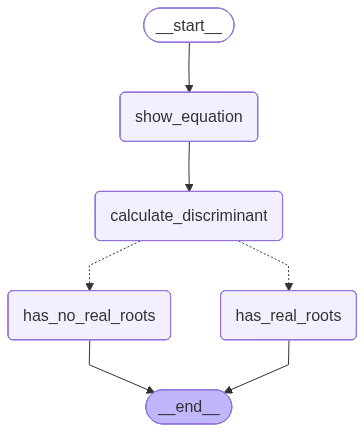

In [17]:
workflow

In [18]:
initial_state={
    'a':4,
    'b':4,
    'c':1
}
workflow.invoke(initial_state)

{'a': 4,
 'b': 4,
 'c': 1,
 'equation': '4x^2 + 4x + 1',
 'discriminant': 0,
 'result': 'Roots: -0.5, -0.5'}